# Data Analysis with Pandas
## PyIU Advanced Python Workshop

Authors: Kristin Baker

Last modified: 6/2/2026

This notebook covers some of the basic mechanics of working with Pandas Dataframes.

## Introduction to Pandas

Pandas is a Python library that lets you work with tabular data easily. Pandas works similarly to an excel spreadsheet in that you store, sort, manipulate, and analyze tabular data sets (e.g., rows and columns). 

As with everything, first we need to import pandas. 

In [9]:
import pandas as pd

There are a couple of ways to make a data frame (df). First, we can add data from existing lists or arrays into a df. Let's generate a couple of random arrays. 

In [17]:
import numpy as np
np.random.seed(1240)
arr1 = np.random.randint(1,high= 1200, size = 1000)

np.random.seed(87)
arr2 = np.random.randint(1,high= 1200, size = 1000)

np.random.seed(2965)
arr3 = np.random.randint(1,high= 1200, size = 1000)

In [49]:
##add it to a dataframe
random_df = pd.DataFrame([arr1,arr2,arr3])
random_df

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,688,1038,366,286,528,550,426,767,1173,376,...,653,680,898,518,1165,629,867,603,997,1034
1,334,700,144,1031,820,573,225,62,1135,788,...,1109,516,503,471,692,604,478,1060,584,374
2,23,1018,457,1067,1132,307,303,2,220,1048,...,280,627,915,445,323,1118,939,1161,641,543


This creates a table with 3 rows with 1000 columns. But maybe we want instead a df with 3 columns and 1000 rows. We can create a df with one array, and then add more columns. Read more about making dfs here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

In [40]:
new_shape_df = pd.DataFrame(arr1, columns = ['random1'])

In [45]:
new_shape_df['random2'],new_shape_df['random3'] = arr2,arr3

More often than not, you will probably want to load in data from a text or csv file. Let's use a an example data using real data from one of Dr. John Salzer emission-line galaxy surveys! 

Reading in data files directly to a data frame can be done with the "read_csv" function. 

Data in text files can be "delimited" or spearated in few different ways, most commonly: spaces, tabs, and commas. For this  

In [93]:
kiss_df = pd.read_csv('kiss_table.txt', delimiter = '\s+')
kiss_df

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Kristin\AppData\Local\Temp\ipykernel_42076\3250083454.py:1: SyntaxWarning: invalid escape sequence '\s'
  kiss_df = pd.read_csv('kiss_table.txt', delimiter = '\s+')


,KISSR,ZS,RA,DEC
0,1226,0.30983,182.36683,43.28083
1,971,0.32825,241.70042,29.18011
2,1751,0.34763,214.19869,42.85322
3,1802,0.42133,218.17136,43.01106
4,867,0.49255,237.39281,29.76547
5,127,0.29640,192.27919,28.95774
6,1963,0.31392,233.10522,43.44244
7,2036,0.31453,237.23344,43.98553
8,2097,0.32011,241.46242,44.09466
9,1541,0.32551,199.78031,43.13696


Sometimes our data files don't have column names (bad practice, don't be like them). We can tell pandas what the column names should be with the key word 'names'. This must be an array of strings with the same length as the number of your columns. Because we are loading in a csv, pandas knows that the delimiter should be a comma, and we don't need to set the delimiter. 

Note, if your input file is all numbers, pandas will automatically read everything in as a float or int. If you are getting errors when reading in because you have strings, try using the key word 'dtype' and setting it equal to str. Read more about read_csv here: https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

In [119]:
kiss_phot_df = pd.read_csv('kiss_photometry.csv',names=['KISSR','u','g','r','i','z'])
kiss_phot_df

,KISSR,u,g,r,i,z
0,1226,20.818,19.686,18.427,18.214,17.461
1,971,19.225,18.690,18.104,18.007,17.389
2,1751,20.948,19.552,18.305,18.097,17.406
3,1802,19.088,18.849,18.985,18.780,18.648
4,867,19.603,19.406,19.547,19.411,19.254
5,127,21.347,20.725,19.428,19.468,19.081
6,1963,20.814,20.108,18.967,18.805,18.302
7,2036,22.324,20.489,18.924,18.549,18.113
8,2097,21.204,20.526,19.132,19.920,19.023
9,1541,19.783,19.121,18.185,18.091,17.508


We can merge two data frames together using the merge function. We can use the key word 'on' to specify what column we want to merge everything on. By setting on to KISSR, we are telling panda to grab all of the information from both dfs associated with a given value in the "KISSR" column and place it into one row in the new df. Read more about merging dfs here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html

In [121]:
kiss_full_df = kiss_df.merge(kiss_phot_df,on='KISSR')
kiss_full_df

,KISSR,ZS,RA,DEC,u,g,r,i,z
0,1226,0.30983,182.36683,43.28083,20.818,19.686,18.427,18.214,17.461
1,971,0.32825,241.70042,29.18011,19.225,18.690,18.104,18.007,17.389
2,1751,0.34763,214.19869,42.85322,20.948,19.552,18.305,18.097,17.406
3,1802,0.42133,218.17136,43.01106,19.088,18.849,18.985,18.780,18.648
4,867,0.49255,237.39281,29.76547,19.603,19.406,19.547,19.411,19.254
5,127,0.29640,192.27919,28.95774,21.347,20.725,19.428,19.468,19.081
6,1963,0.31392,233.10522,43.44244,20.814,20.108,18.967,18.805,18.302
7,2036,0.31453,237.23344,43.98553,22.324,20.489,18.924,18.549,18.113
8,2097,0.32011,241.46242,44.09466,21.204,20.526,19.132,19.920,19.023
9,1541,0.32551,199.78031,43.13696,19.783,19.121,18.185,18.091,17.508


Say we want to pass our df through a function we have defined. Since this is a photometry df, let's use a color index as an example. 

Let's find the g - r color for all of our galaxies. First, we define a function called "find_color," which inputs two magnitudes, subtracts them, and outputs the color. We can create new column called "g-r." we can pass it through the function by converting our column to a np array with "to_numpy" and setting the dtype to float.

In [125]:
def find_color(mag1, mag2):
    return mag1 - mag2

kiss_full_df['g-r'] = find_color(kiss_full_df['g'].to_numpy(dtype=float),
                                kiss_full_df['r'].to_numpy(dtype=float))
kiss_full_df

,KISSR,ZS,RA,DEC,u,g,r,i,z,g-r
0,1226,0.30983,182.36683,43.28083,20.818,19.686,18.427,18.214,17.461,1.259
1,971,0.32825,241.70042,29.18011,19.225,18.690,18.104,18.007,17.389,0.586
2,1751,0.34763,214.19869,42.85322,20.948,19.552,18.305,18.097,17.406,1.247
3,1802,0.42133,218.17136,43.01106,19.088,18.849,18.985,18.780,18.648,-0.136
4,867,0.49255,237.39281,29.76547,19.603,19.406,19.547,19.411,19.254,-0.141
5,127,0.29640,192.27919,28.95774,21.347,20.725,19.428,19.468,19.081,1.297
6,1963,0.31392,233.10522,43.44244,20.814,20.108,18.967,18.805,18.302,1.141
7,2036,0.31453,237.23344,43.98553,22.324,20.489,18.924,18.549,18.113,1.565
8,2097,0.32011,241.46242,44.09466,21.204,20.526,19.132,19.920,19.023,1.394
9,1541,0.32551,199.78031,43.13696,19.783,19.121,18.185,18.091,17.508,0.936


Sometimes, we may want to sort our df based on a certain column. We can use sort_values to do this. The main key we need to set is the "by" key. Pandas default sort from smallest to largest with "ascending" key. When we are sorting by columns with numbers, it is best to set "key=pd.to_numeric." This tells pandas that the dtype of your column is a float.  

Read more about sort_values here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html

In [153]:
kiss_full_df.sort_values(by='g',key=pd.to_numeric)

,KISSR,ZS,RA,DEC,u,g,r,i,z,g-r
1,971,0.32825,241.70042,29.18011,19.225,18.690,18.104,18.007,17.389,0.586
3,1802,0.42133,218.17136,43.01106,19.088,18.849,18.985,18.780,18.648,-0.136
9,1541,0.32551,199.78031,43.13696,19.783,19.121,18.185,18.091,17.508,0.936
26,1825,0.33112,219.08469,43.88378,19.513,19.194,18.819,18.966,18.379,0.375
10,1561,0.33756,201.01772,43.56844,19.525,19.248,18.322,18.021,17.410,0.926
4,867,0.49255,237.39281,29.76547,19.603,19.406,19.547,19.411,19.254,-0.141
25,1516,0.32766,198.95600,43.57503,19.719,19.475,18.956,19.589,18.955,0.519
30,225,0.35822,197.54067,29.29527,19.835,19.551,19.246,19.347,19.028,0.305
2,1751,0.34763,214.19869,42.85322,20.948,19.552,18.305,18.097,17.406,1.247
22,1508,0.29397,198.67200,43.72399,19.797,19.586,19.170,19.655,19.197,0.416


We can use conditional statements to select out galaxies we may want. For example, let's select galaxies with g magnitudes brighter than 20 (i.e., smaller than 20 ... thanks magnitude system)

In [158]:
kiss_bright_df = kiss_full_df[kiss_full_df['g'].astype(float) <= 20.0 ]
kiss_bright_df

,KISSR,ZS,RA,DEC,u,g,r,i,z,g-r
0,1226,0.30983,182.36683,43.28083,20.818,19.686,18.427,18.214,17.461,1.259
1,971,0.32825,241.70042,29.18011,19.225,18.690,18.104,18.007,17.389,0.586
2,1751,0.34763,214.19869,42.85322,20.948,19.552,18.305,18.097,17.406,1.247
3,1802,0.42133,218.17136,43.01106,19.088,18.849,18.985,18.780,18.648,-0.136
4,867,0.49255,237.39281,29.76547,19.603,19.406,19.547,19.411,19.254,-0.141
9,1541,0.32551,199.78031,43.13696,19.783,19.121,18.185,18.091,17.508,0.936
10,1561,0.33756,201.01772,43.56844,19.525,19.248,18.322,18.021,17.410,0.926
11,603,0.34200,224.81883,29.81045,20.805,19.737,18.484,18.218,17.879,1.253
22,1508,0.29397,198.67200,43.72399,19.797,19.586,19.170,19.655,19.197,0.416
23,1290,0.30496,185.60078,43.18965,20.054,19.797,19.454,19.760,19.182,0.343


You can even plot columns in your df. Let's do a histogram of the g magnitudes for our full df. 

Text(0, 0.5, 'count')

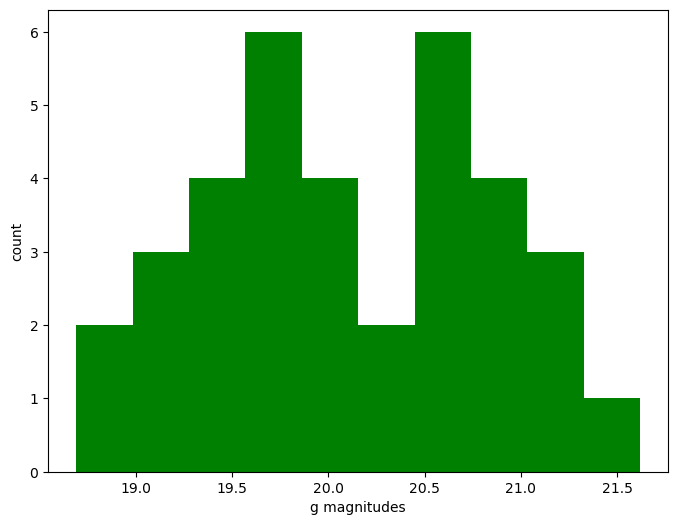

In [169]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (8,6))

plt.hist(kiss_full_df['g'].astype(float),color = 'green')
plt.xlabel("g magnitudes")
plt.ylabel("count")

You can save your df to a csv file using the to_csv function.

In [135]:
kiss_full_df.to_csv('kiss_dataframe_full.csv',index=False)

You can also save specific colums. 

In [137]:
kiss_full_df[['KISSR','RA','DEC']].to_csv('kiss_dataframe_coords.csv',index=False)